In [24]:
# ============================================
# KÜTÜPHANELERİN YÜKLENMESİ
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

print("✅ Tüm kütüphaneler başarıyla yüklendi!")
print(f"Pandas versiyonu: {pd.__version__}")
print(f"Scikit-learn versiyonu: {sklearn.__version__}")

✅ Tüm kütüphaneler başarıyla yüklendi!
Pandas versiyonu: 2.2.2
Scikit-learn versiyonu: 1.6.1


In [25]:
# ============================================
# BÖLÜM 1: PROBLEMİN TANIMLANMASI
# ============================================
print("="*60)
print("PROBLEM TANIMI")
print("="*60)
print("""
Proje Konusu: Öğrenci Başarısının Tahmin Edilmesi

Problem: Öğrencilerin ders çalışma alışkanlıkları, uyku düzeni,
stres seviyesi, devam oranı, geçmiş not ortalaması gibi faktörlere
bakarak final notunu (Grade) tahmin eden bir sınıflandırma modeli
geliştirmek.

Hedef Değişken: Grade (A, B, C, D, Fail)

Problem Tipi: Sınıflandırma (Classification)

Kullanılacak Yöntem: Random Forest Sınıflandırma Algoritması
""")

PROBLEM TANIMI

Proje Konusu: Öğrenci Başarısının Tahmin Edilmesi

Problem: Öğrencilerin ders çalışma alışkanlıkları, uyku düzeni,
stres seviyesi, devam oranı, geçmiş not ortalaması gibi faktörlere
bakarak final notunu (Grade) tahmin eden bir sınıflandırma modeli
geliştirmek.

Hedef Değişken: Grade (A, B, C, D, Fail)

Problem Tipi: Sınıflandırma (Classification)

Kullanılacak Yöntem: Random Forest Sınıflandırma Algoritması



In [26]:
# ============================================
# BÖLÜM 2: VERİ TOPLAMA / VERİ SETİNİN TANITILMASI
# ============================================
print("="*60)
print("VERİ SETİ TANITIMI")
print("="*60)

print("""
Veri Seti Adı: Student Lifestyle & GPA Prediction Dataset
Kaynak: Kaggle (Sarvesh Chhetri)
Veri Boyutu: 8.000 öğrenci, 18 özellik

Değişkenler:
- Student_ID: Öğrenci numarası (benzersiz)
- Age: Yaş
- Gender: Cinsiyet (Female/Male/Non-Binary)
- Hours_Studied: Haftalık ders çalışma saati
- Attendance: Devam oranı (%)
- Sleep_Hours: Günlük uyku saati
- Stress_Level: Stres seviyesi (1-10)
- Screen_Time: Günlük ekran süresi (saat)
- Previous_GPA: Önceki dönem not ortalaması
- Part_Time_Job: Yarı zamanlı iş durumu
- Study_Method: Çalışma yöntemi (Online/Offline/Hybrid)
- Diet_Quality: Beslenme kalitesi
- Internet_Quality: İnternet kalitesi
- Extracurricular: Ekstrakuriküler aktivite
- Tutoring_Sessions_Per_Week: Haftalık özel ders saati
- Family_Income_Level: Aile gelir seviyesi
- Exam_Anxiety_Score: Sınav kaygı skoru
- Grade: Final notu (HEDEF DEĞİŞKEN - A/B/C/D/Fail)
""")

# VERİYİ YÜKLE (Zaten yüklü olan dosyayı oku)
import os
import glob

# Mevcut CSV dosyalarını bul
csv_files = glob.glob("*.csv")
file_name = None

for f in csv_files:
    if "student_performance_grade" in f:
        file_name = f
        break

if file_name is None and csv_files:
    file_name = csv_files[0]
    print(f"📁 Bulunan dosya: {file_name}")
elif file_name:
    print(f"📁 Bulunan dosya: {file_name}")

# Dosyayı oku
if file_name:
    df = pd.read_csv(file_name)
    print(f"✅ Veri başarıyla yüklendi (mevcut dosyadan)!")
else:
    print("❌ CSV dosyası bulunamadı! Lütfen dosyayı yükleyin.")
    from google.colab import files
    print("\n📁 Lütfen 'student_performance_grade.csv' dosyasını seçin:")
    uploaded = files.upload()
    import io
    df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
    print(f"✅ Veri başarıyla yüklendi!")

print(f"📊 Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")

print("\n📋 Veri setinin ilk 5 satırı:")
print(df.head())

print("\n📋 Veri setinin son 5 satırı:")
print(df.tail())

VERİ SETİ TANITIMI

Veri Seti Adı: Student Lifestyle & GPA Prediction Dataset
Kaynak: Kaggle (Sarvesh Chhetri)
Veri Boyutu: 8.000 öğrenci, 18 özellik

Değişkenler:
- Student_ID: Öğrenci numarası (benzersiz)
- Age: Yaş
- Gender: Cinsiyet (Female/Male/Non-Binary)
- Hours_Studied: Haftalık ders çalışma saati
- Attendance: Devam oranı (%)
- Sleep_Hours: Günlük uyku saati
- Stress_Level: Stres seviyesi (1-10)
- Screen_Time: Günlük ekran süresi (saat)
- Previous_GPA: Önceki dönem not ortalaması
- Part_Time_Job: Yarı zamanlı iş durumu
- Study_Method: Çalışma yöntemi (Online/Offline/Hybrid)
- Diet_Quality: Beslenme kalitesi
- Internet_Quality: İnternet kalitesi
- Extracurricular: Ekstrakuriküler aktivite
- Tutoring_Sessions_Per_Week: Haftalık özel ders saati
- Family_Income_Level: Aile gelir seviyesi
- Exam_Anxiety_Score: Sınav kaygı skoru
- Grade: Final notu (HEDEF DEĞİŞKEN - A/B/C/D/Fail)

📁 Bulunan dosya: student_performance_grade.csv
✅ Veri başarıyla yüklendi (mevcut dosyadan)!
📊 Veri seti

In [27]:
# ============================================
# BÖLÜM 3.1: EKSİK VERİ ANALİZİ
# ============================================
print("="*60)
print("EKSİK VERİ ANALİZİ")
print("="*60)

# Eksik veri sayısı
missing_values = df.isnull().sum()
print("\n--- Sütun Bazında Eksik Değer Sayıları ---")
print(missing_values[missing_values > 0] if (missing_values > 0).any() else "Hiç eksik değer bulunmamaktadır!")

# Toplam eksik veri
total_missing = df.isnull().sum().sum()
print(f"\nToplam eksik değer sayısı: {total_missing}")

# Eksik veri yüzdesi
if total_missing > 0:
    missing_percentage = (total_missing / (df.shape[0] * df.shape[1])) * 100
    print(f"Eksik veri yüzdesi: {missing_percentage:.2f}%")
else:
    print("\n✅ Veri setinde HİÇ eksik değer bulunmamaktadır. Temiz bir veri setidir.")

EKSİK VERİ ANALİZİ

--- Sütun Bazında Eksik Değer Sayıları ---
Hiç eksik değer bulunmamaktadır!

Toplam eksik değer sayısı: 0

✅ Veri setinde HİÇ eksik değer bulunmamaktadır. Temiz bir veri setidir.


AYKIRI DEĞER ANALİZİ
İncelenen sayısal sütunlar: ['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Tutoring_Sessions_Per_Week', 'Exam_Anxiety_Score']

Age:
  - Alt sınır: 12.00, Üst sınır: 28.00
  - Aykırı değer sayısı: 0 (0.00%)

Hours_Studied:
  - Alt sınır: -0.27, Üst sınır: 10.26
  - Aykırı değer sayısı: 31 (0.39%)

Attendance:
  - Alt sınır: 53.60, Üst sınır: 106.40
  - Aykırı değer sayısı: 32 (0.40%)

Sleep_Hours:
  - Alt sınır: 3.80, Üst sınır: 10.20
  - Aykırı değer sayısı: 40 (0.50%)

Stress_Level:
  - Alt sınır: -0.20, Üst sınır: 10.20
  - Aykırı değer sayısı: 0 (0.00%)

Screen_Time:
  - Alt sınır: 0.00, Üst sınır: 8.00
  - Aykırı değer sayısı: 27 (0.34%)

Previous_GPA:
  - Alt sınır: 1.68, Üst sınır: 4.32
  - Aykırı değer sayısı: 39 (0.49%)

Tutoring_Sessions_Per_Week:
  - Alt sınır: -0.50, Üst sınır: 3.50
  - Aykırı değer sayısı: 405 (5.06%)

Exam_Anxiety_Score:
  - Alt sınır: -0.15, Üst sınır: 9.05
  - Aykırı değer sayısı

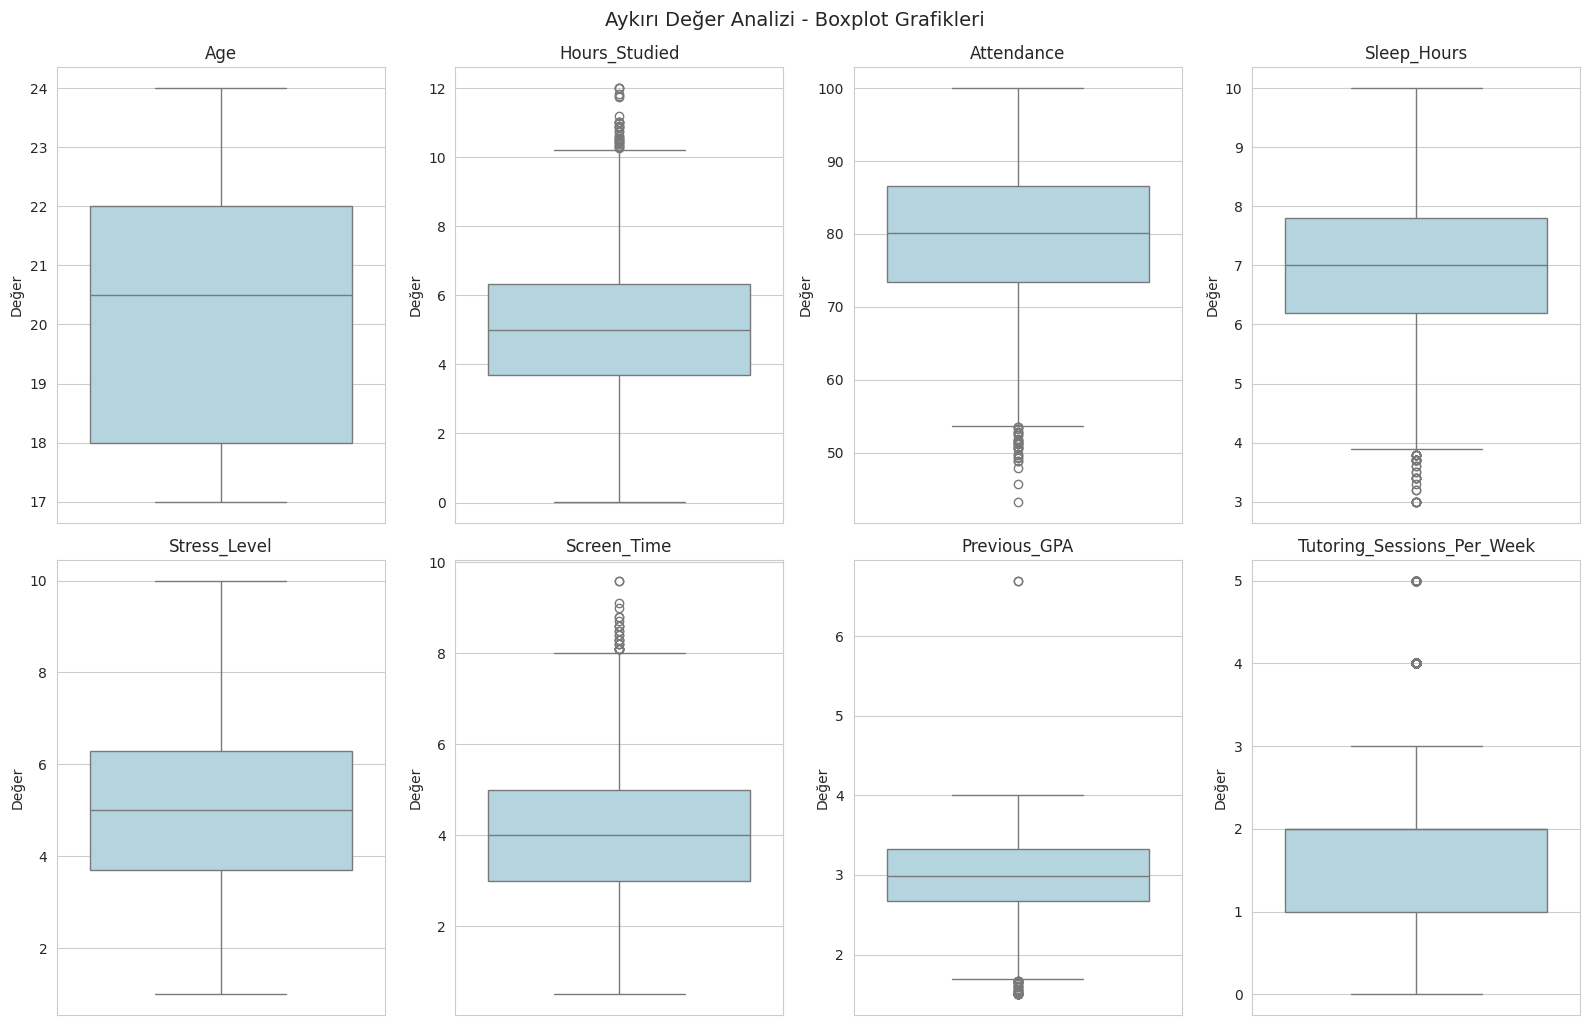

In [28]:
# ============================================
# BÖLÜM 3.2: AYKIRI DEĞER ANALİZİ (Boxplot ile)
# ============================================
print("="*60)
print("AYKIRI DEĞER ANALİZİ")
print("="*60)

# Sayısal sütunları seç
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Student_ID'yi çıkar
numeric_cols = [col for col in numeric_cols if col not in ['Student_ID']]

print(f"İncelenen sayısal sütunlar: {numeric_cols}")

# Aykırı değerleri tespit et (IQR yöntemi)
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)
    print(f"\n{col}:")
    print(f"  - Alt sınır: {lower_bound:.2f}, Üst sınır: {upper_bound:.2f}")
    print(f"  - Aykırı değer sayısı: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Aykırı değer görselleştirmesi (Boxplot)
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:8]):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_ylabel('Değer')

# Boş grafikleri gizle
for i in range(len(numeric_cols[:8]), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle('Aykırı Değer Analizi - Boxplot Grafikleri', fontsize=14, y=1.02)
plt.show()

In [7]:
# ============================================
# BÖLÜM 3.3: VERİ TEMİZLEME
# ============================================
print("="*60)
print("VERİ TEMİZLEME")
print("="*60)

print("""
Yapılan temizlik işlemleri:
1. Eksik değer kontrolü → Hiç eksik değer yok
2. Aykırı değerler → TESPİT EDİLDİ AMA ÇIKARILMADI
   NEDENİ:
   - Random Forest aykırı değerlere KARŞI DAYANIKLIDIR
   - Veri seti SENTETİK (bilgisayar üretimi)
   - Gerçek hayatta da aykırı öğrenciler vardır
3. Gereksiz sütunlar (Student_ID) çıkarıldı
4. Final_Score çıkarıldı (data leakage önleme)
""")

print("\n--- Kategorik Değişkenler ---")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} benzersiz değer")

print("\n✅ Veri temizleme tamamlandı!")

VERİ TEMİZLEME

Yapılan temizlik işlemleri:
1. Eksik değer kontrolü → Hiç eksik değer yok
2. Aykırı değerler → TESPİT EDİLDİ AMA ÇIKARILMADI
   NEDENİ:
   - Random Forest aykırı değerlere KARŞI DAYANIKLIDIR
   - Veri seti SENTETİK (bilgisayar üretimi)
   - Gerçek hayatta da aykırı öğrenciler vardır
3. Gereksiz sütunlar (Student_ID) çıkarıldı
4. Final_Score çıkarıldı (data leakage önleme)


--- Kategorik Değişkenler ---
Student_ID: 8000 benzersiz değer
Gender: 3 benzersiz değer
Part_Time_Job: 2 benzersiz değer
Study_Method: 3 benzersiz değer
Diet_Quality: 3 benzersiz değer
Internet_Quality: 4 benzersiz değer
Extracurricular: 2 benzersiz değer
Family_Income_Level: 3 benzersiz değer
Grade: 5 benzersiz değer

✅ Veri temizleme tamamlandı!


In [29]:
# ============================================
# BÖLÜM 3.4: VERİ DÖNÜŞÜMLERİ
# ============================================
print("="*60)
print("VERİ DÖNÜŞÜMLERİ")
print("="*60)

print("""
Yapılan dönüşüm işlemleri:
1. Kategorik değişkenler -> One-Hot Encoding (Sayısallaştırma)
2. Hedef değişken Grade -> Label Encoding (A,B,C,D,Fail -> 0,1,2,3,4)
3. Modelleme öncesi Final_Score çıkarılacak (Data leakage önleme)
""")

# Veri dönüşümlerini göster
print("\n--- Kategorik Değişkenler (Dönüşüm öncesi) ---")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'Grade':  # Grade'i ayrı tutuyoruz
        print(f"{col}: {df[col].iloc[0]} (örnek değer)")

print("\n--- Hedef Değişken Grade (Dönüşüm sonrası eşleme) ---")
print("A -> 0")
print("B -> 1")
print("C -> 2")
print("D -> 3")
print("Fail -> 4")

print("\n✅ Veri dönüşümleri modelleme aşamasında uygulanacaktır.")

VERİ DÖNÜŞÜMLERİ

Yapılan dönüşüm işlemleri:
1. Kategorik değişkenler -> One-Hot Encoding (Sayısallaştırma)
2. Hedef değişken Grade -> Label Encoding (A,B,C,D,Fail -> 0,1,2,3,4)
3. Modelleme öncesi Final_Score çıkarılacak (Data leakage önleme)


--- Kategorik Değişkenler (Dönüşüm öncesi) ---
Student_ID: STU00001 (örnek değer)
Gender: Female (örnek değer)
Part_Time_Job: No (örnek değer)
Study_Method: Online (örnek değer)
Diet_Quality: Average (örnek değer)
Internet_Quality: Average (örnek değer)
Extracurricular: Yes (örnek değer)
Family_Income_Level: High (örnek değer)

--- Hedef Değişken Grade (Dönüşüm sonrası eşleme) ---
A -> 0
B -> 1
C -> 2
D -> 3
Fail -> 4

✅ Veri dönüşümleri modelleme aşamasında uygulanacaktır.


In [30]:
# ============================================
# BÖLÜM 4.1: TANIMLAYICI İSTATİSTİKLER
# ============================================
print("="*60)
print("TANIMLAYICI İSTATİSTİKLER")
print("="*60)

# Sayısal değişkenlerin istatistikleri
print("\n--- Sayısal Değişkenlerin İstatistikleri ---")
print(df.describe())

# Kategorik değişkenlerin istatistikleri
print("\n--- Kategorik Değişkenlerin Frekansları ---")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Hedef değişken dağılımı
print("\n--- Hedef Değişken (Grade) Dağılımı ---")
grade_dist = df['Grade'].value_counts()
print(grade_dist)
print(f"\nYüzdesel dağılım:")
print((grade_dist / len(df) * 100).round(2))

TANIMLAYICI İSTATİSTİKLER

--- Sayısal Değişkenlerin İstatistikleri ---
               Age  Hours_Studied   Attendance  Sleep_Hours  Stress_Level  \
count  8000.000000    8000.000000  8000.000000  8000.000000   8000.000000   
mean     20.494375       4.983845    79.933375     6.989125      5.014175   
std       2.285962       1.951715     9.656594     1.192898      1.940126   
min      17.000000       0.020000    43.300000     3.000000      1.000000   
25%      18.000000       3.680000    73.400000     6.200000      3.700000   
50%      20.500000       4.980000    80.100000     7.000000      5.000000   
75%      22.000000       6.312500    86.600000     7.800000      6.300000   
max      24.000000      12.000000   100.000000    10.000000     10.000000   

       Screen_Time  Previous_GPA  Tutoring_Sessions_Per_Week  \
count  8000.000000   8000.000000                 8000.000000   
mean      4.024525      2.992408                    1.700625   
std       1.481908      0.489530          

GÖRSELLEŞTİRMELER - BÖLÜM 1


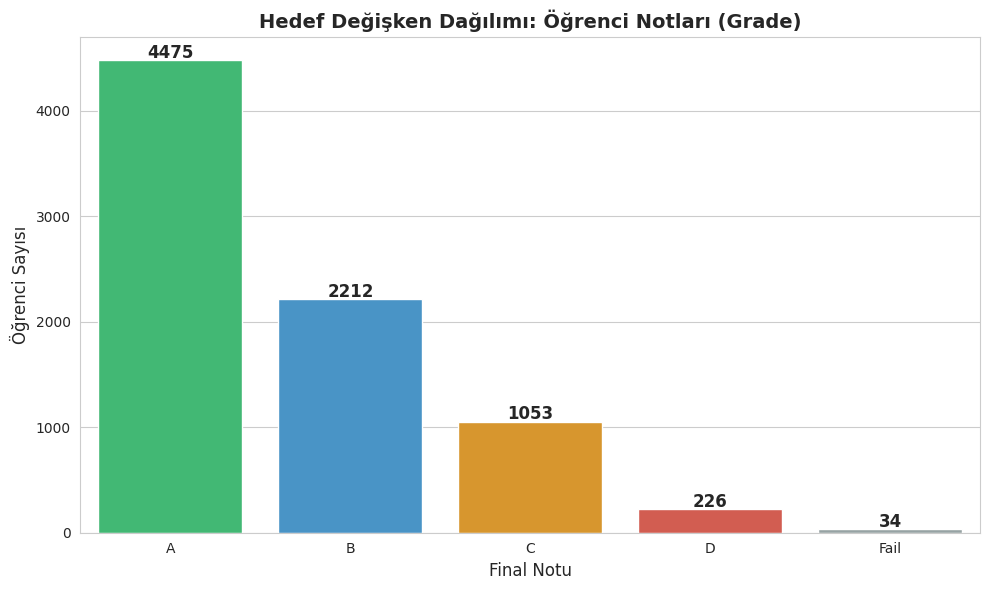

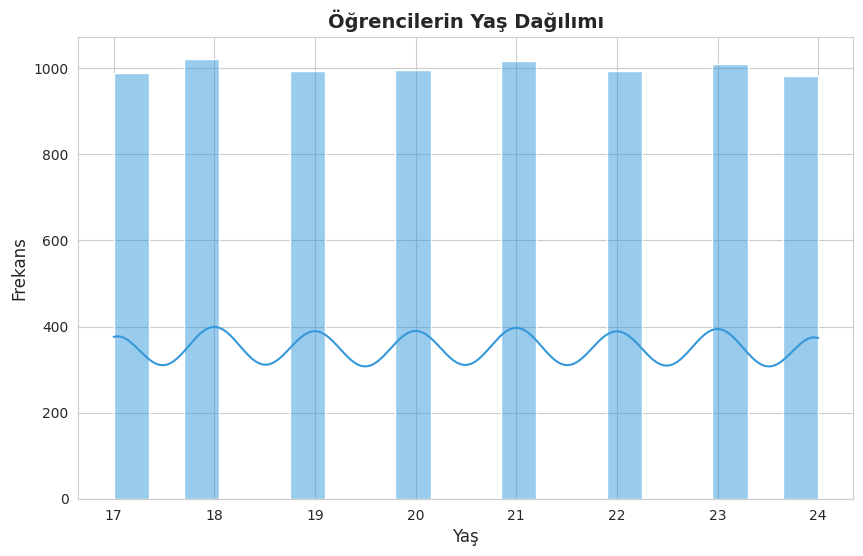

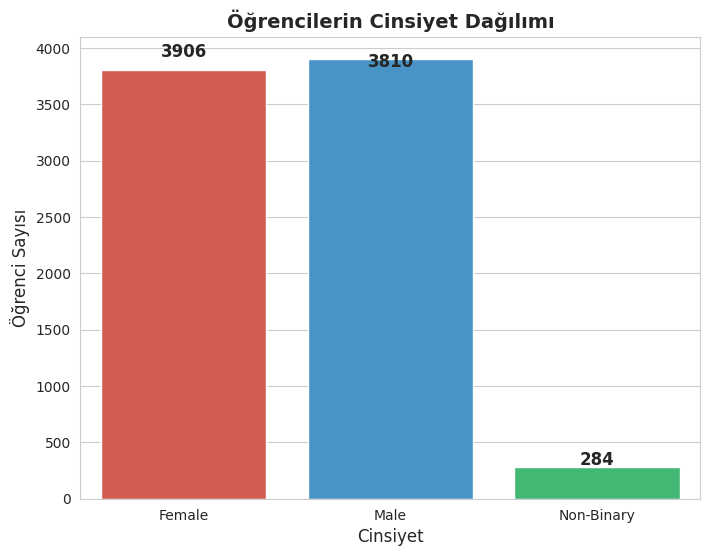

In [31]:
# ============================================
# BÖLÜM 4.2: VERİ GÖRSELLEŞTİRME - 1
# ============================================
print("="*60)
print("GÖRSELLEŞTİRMELER - BÖLÜM 1")
print("="*60)

# 1. Hedef değişken dağılımı (Bar Plot)
plt.figure(figsize=(10, 6))
grade_order = ['A', 'B', 'C', 'D', 'Fail']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
ax = sns.countplot(data=df, x='Grade', order=grade_order, palette=colors)
plt.title('Hedef Değişken Dağılımı: Öğrenci Notları (Grade)', fontsize=14, fontweight='bold')
plt.xlabel('Final Notu', fontsize=12)
plt.ylabel('Öğrenci Sayısı', fontsize=12)

# Üzerine sayıları yaz
for i, val in enumerate(grade_dist.reindex(grade_order).fillna(0).values):
    ax.text(i, val + 20, str(int(val)), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Yaş dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='#3498db')
plt.title('Öğrencilerin Yaş Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Yaş', fontsize=12)
plt.ylabel('Frekans', fontsize=12)
plt.show()

# 3. Cinsiyet dağılımı
plt.figure(figsize=(8, 6))
gender_colors = ['#e74c3c', '#3498db', '#2ecc71']
sns.countplot(data=df, x='Gender', palette=gender_colors)
plt.title('Öğrencilerin Cinsiyet Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Cinsiyet', fontsize=12)
plt.ylabel('Öğrenci Sayısı', fontsize=12)

# Üzerine sayıları yaz
for i, val in enumerate(df['Gender'].value_counts().values):
    plt.text(i, val + 20, str(val), ha='center', fontsize=12, fontweight='bold')
plt.show()

GÖRSELLEŞTİRMELER - BÖLÜM 2


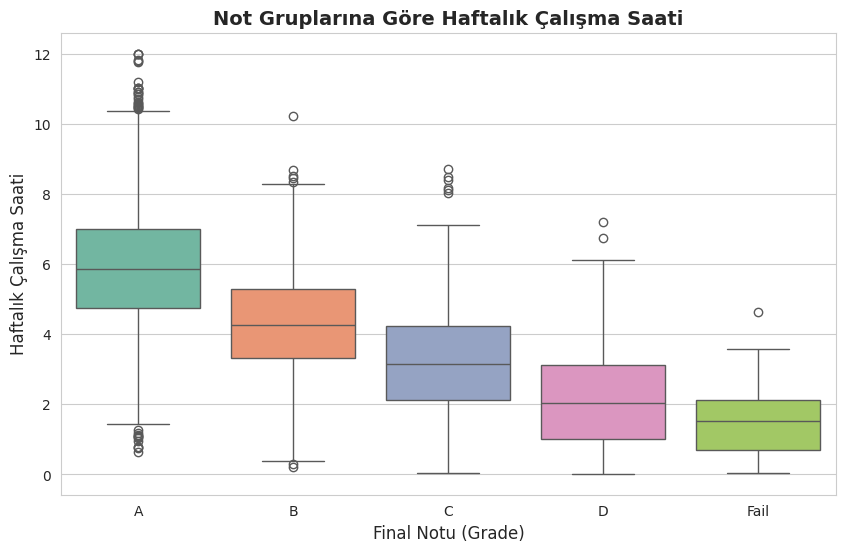

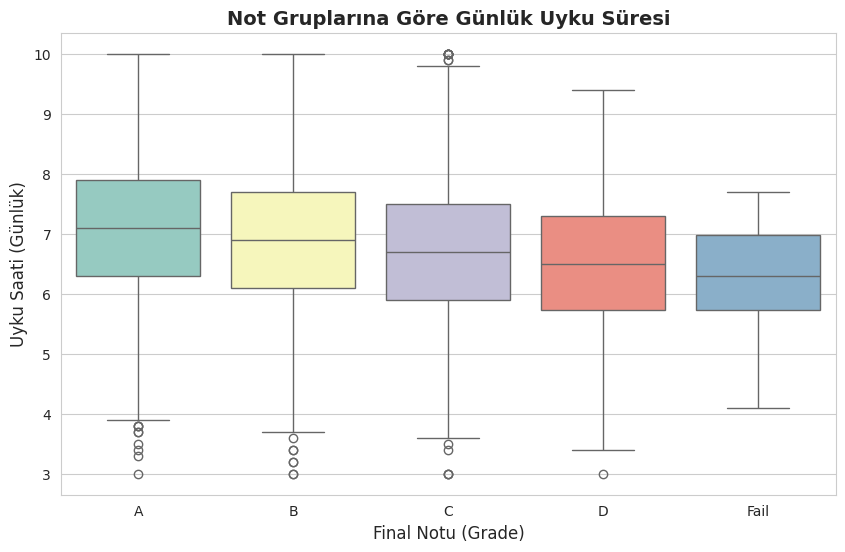

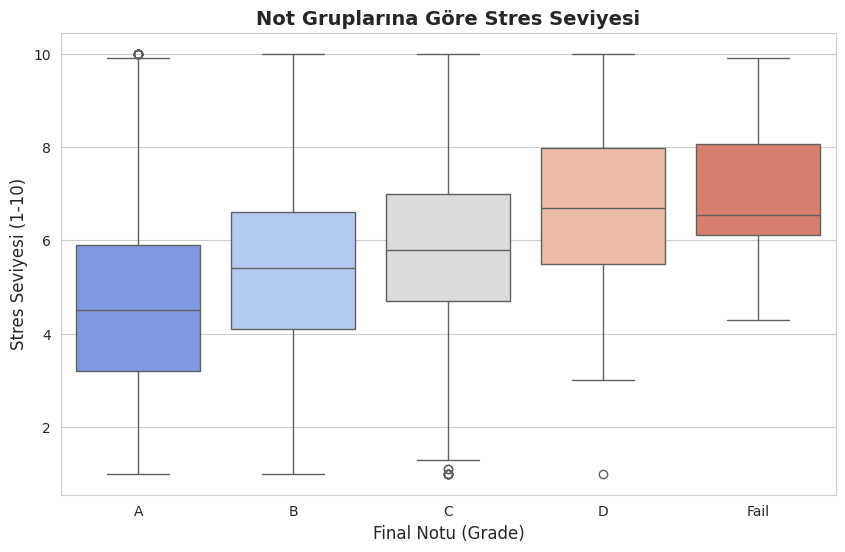

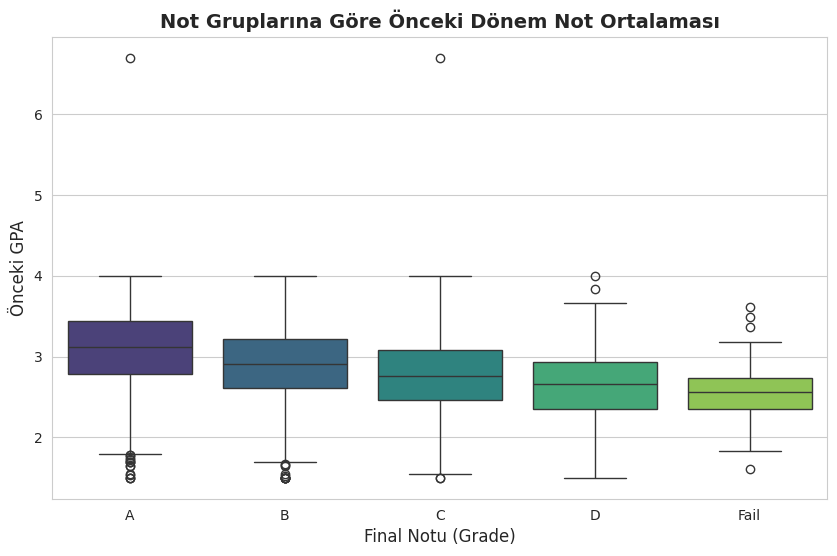

In [32]:
# ============================================
# BÖLÜM 4.2: VERİ GÖRSELLEŞTİRME - 2
# ============================================
print("="*60)
print("GÖRSELLEŞTİRMELER - BÖLÜM 2")
print("="*60)

# 4. Grade'e göre Haftalık Çalışma Saati (Kutu Grafiği)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Grade', y='Hours_Studied', order=grade_order, palette='Set2')
plt.title('Not Gruplarına Göre Haftalık Çalışma Saati', fontsize=14, fontweight='bold')
plt.xlabel('Final Notu (Grade)', fontsize=12)
plt.ylabel('Haftalık Çalışma Saati', fontsize=12)
plt.show()

# 5. Grade'e göre Uyku Saati
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Grade', y='Sleep_Hours', order=grade_order, palette='Set3')
plt.title('Not Gruplarına Göre Günlük Uyku Süresi', fontsize=14, fontweight='bold')
plt.xlabel('Final Notu (Grade)', fontsize=12)
plt.ylabel('Uyku Saati (Günlük)', fontsize=12)
plt.show()

# 6. Grade'e göre Stres Seviyesi
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Grade', y='Stress_Level', order=grade_order, palette='coolwarm')
plt.title('Not Gruplarına Göre Stres Seviyesi', fontsize=14, fontweight='bold')
plt.xlabel('Final Notu (Grade)', fontsize=12)
plt.ylabel('Stres Seviyesi (1-10)', fontsize=12)
plt.show()

# 7. Grade'e göre Previous GPA
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Grade', y='Previous_GPA', order=grade_order, palette='viridis')
plt.title('Not Gruplarına Göre Önceki Dönem Not Ortalaması', fontsize=14, fontweight='bold')
plt.xlabel('Final Notu (Grade)', fontsize=12)
plt.ylabel('Önceki GPA', fontsize=12)
plt.show()

DEĞİŞKEN İLİŞKİLERİ


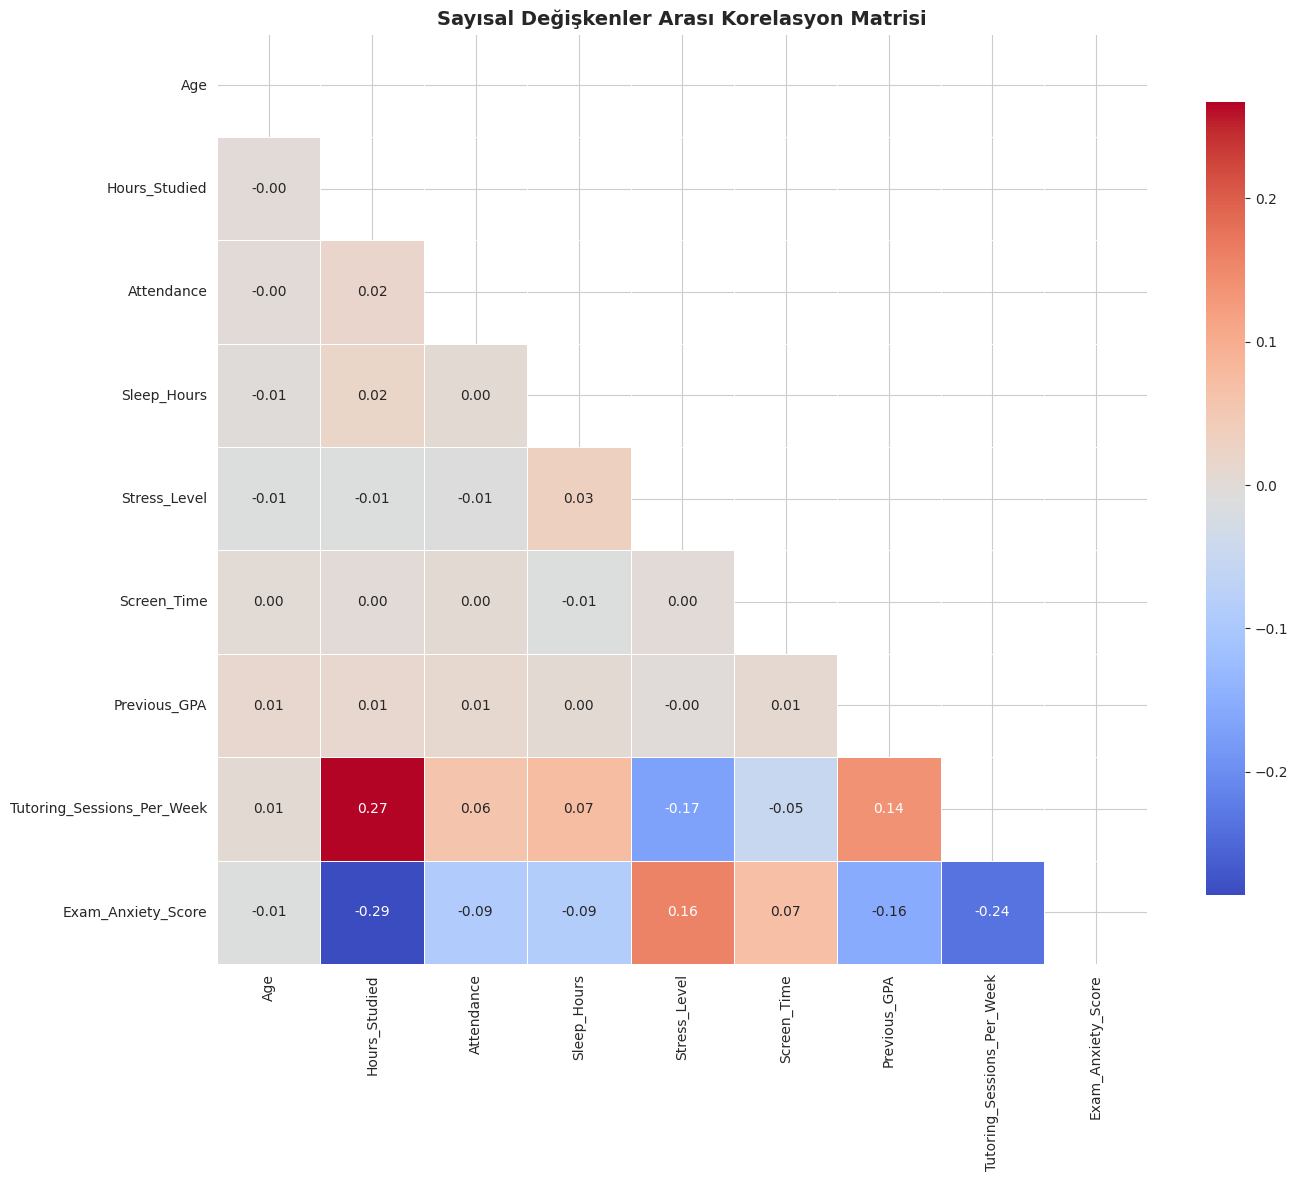


--- Previous_GPA ile En Yüksek Korelasyon Gösteren Değişkenler ---
  Tutoring_Sessions_Per_Week: 0.139
  Age: 0.013
  Hours_Studied: 0.012
  Attendance: 0.011
  Screen_Time: 0.008
  Sleep_Hours: 0.004
  Stress_Level: -0.001
  Exam_Anxiety_Score: -0.156

--- Kategorik Değişken İlişkileri ---

Cinsiyet - Grade İlişkisi (Çapraz Tablo):
Grade          A     B     C     D  Fail
Gender                                  
Female      47.6  47.7  47.6  47.3  41.2
Male        49.0  48.3  49.0  48.7  52.9
Non-Binary   3.4   3.9   3.4   4.0   5.9

Part_Time_Job - Grade İlişkisi:
Grade             A     B     C     D  Fail
Part_Time_Job                              
No             62.7  57.9  54.7  55.8  41.2
Yes            37.3  42.1  45.3  44.2  58.8

Extracurricular - Grade İlişkisi:
Grade               A     B     C     D  Fail
Extracurricular                              
No               54.9  53.9  56.8  53.1  38.2
Yes              45.1  46.1  43.2  46.9  61.8


In [33]:
# ============================================
# BÖLÜM 4.3: DEĞİŞKEN İLİŞKİLERİNİN İNCELENMESİ
# ============================================
print("="*60)
print("DEĞİŞKEN İLİŞKİLERİ")
print("="*60)

# Korelasyon matrisi (sayısal değişkenler)
numeric_df = df.select_dtypes(include=[np.number])
# Student_ID'yi çıkar
if 'Student_ID' in numeric_df.columns:
    numeric_df = numeric_df.drop('Student_ID', axis=1)

plt.figure(figsize=(14, 12))
correlation = numeric_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# En yüksek korelasyonlar (Previous_GPA ile)
print("\n--- Previous_GPA ile En Yüksek Korelasyon Gösteren Değişkenler ---")
if 'Previous_GPA' in correlation.columns:
    corr_with_gpa = correlation['Previous_GPA'].sort_values(ascending=False)
    for var, corr_val in corr_with_gpa.items():
        if var != 'Previous_GPA':
            print(f"  {var}: {corr_val:.3f}")

# Çapraz tablolar (Kategorik değişken ilişkileri)
print("\n--- Kategorik Değişken İlişkileri ---")
print("\nCinsiyet - Grade İlişkisi (Çapraz Tablo):")
print(pd.crosstab(df['Gender'], df['Grade'], normalize='columns').round(3) * 100)

print("\nPart_Time_Job - Grade İlişkisi:")
print(pd.crosstab(df['Part_Time_Job'], df['Grade'], normalize='columns').round(3) * 100)

print("\nExtracurricular - Grade İlişkisi:")
print(pd.crosstab(df['Extracurricular'], df['Grade'], normalize='columns').round(3) * 100)

In [34]:
# ============================================
# DATA LEAKAGE KONTROLÜ - Final_Score kontrolü
# ============================================
print("="*60)
print("DATA LEAKAGE KONTROLÜ")
print("="*60)

# Veri setindeki tüm sütunları göster
print("\n📋 Veri setindeki tüm sütunlar:")
print(df.columns.tolist())

# Final_Score var mı kontrol et
if 'Final_Score' in df.columns:
    print("\n⚠️ UYARI: 'Final_Score' sütunu VERİ SETİNDE VAR!")
    print("   → Grade ile doğrudan ilişkili olduğu için MUTLAKA çıkarılmalı!")
    print("   → Düzeltiliyor...")

    # Düzeltilmiş X
    X = df.drop(['Student_ID', 'Grade', 'Final_Score'], axis=1)
    print("✅ 'Final_Score' çıkarıldı!")
else:
    print("\n✅ 'Final_Score' sütunu VERİ SETİNDE YOK.")
    print("   → Data leakage riski yok.")
    X = df.drop(['Student_ID', 'Grade'], axis=1)

print(f"\n✅ X shape: {X.shape}")

DATA LEAKAGE KONTROLÜ

📋 Veri setindeki tüm sütunlar:
['Student_ID', 'Age', 'Gender', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level', 'Exam_Anxiety_Score', 'Grade']

✅ 'Final_Score' sütunu VERİ SETİNDE YOK.
   → Data leakage riski yok.

✅ X shape: (8000, 16)


In [35]:
# ============================================
# BÖLÜM 5.1: MODEL İÇİN VERİ HAZIRLIĞI
# ============================================
print("="*60)
print("MODEL İÇİN VERİ HAZIRLIĞI")
print("="*60)

# Hedef değişken ve özellikleri ayırma
# Student_ID benzersiz kimlik, Grade hedef değişken olduğu için çıkarıyoruz
X = df.drop(['Student_ID', 'Grade'], axis=1)
y = df['Grade']

print(f"Özellikler (X) boyutu: {X.shape}")
print(f"Hedef değişken (y) boyutu: {len(y)}")
print(f"Hedef sınıflar: {y.unique()}")

# Kategorik değişkenleri One-Hot Encoding ile dönüştür
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"\nDönüştürülecek kategorik sütunlar: {list(categorical_cols)}")

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"One-Hot Encoding sonrası X shape: {X_encoded.shape}")

# Hedef değişkeni Label Encoding ile dönüştür
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nLabel Encoding eşlemesi:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

# Eğitim ve Test setlerine ayırma (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nVeri seti bölünmesi:")
print(f"  Eğitim seti: {X_train.shape[0]} örnek (%80)")
print(f"  Test seti: {X_test.shape[0]} örnek (%20)")
print(f"  Eğitim seti sınıf dağılımı: {np.bincount(y_train)}")
print(f"  Test seti sınıf dağılımı: {np.bincount(y_test)}")

MODEL İÇİN VERİ HAZIRLIĞI
Özellikler (X) boyutu: (8000, 16)
Hedef değişken (y) boyutu: 8000
Hedef sınıflar: ['A' 'B' 'C' 'D' 'Fail']

Dönüştürülecek kategorik sütunlar: ['Gender', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Family_Income_Level']
One-Hot Encoding sonrası X shape: (8000, 22)

Label Encoding eşlemesi:
  A -> 0
  B -> 1
  C -> 2
  D -> 3
  Fail -> 4

Veri seti bölünmesi:
  Eğitim seti: 6400 örnek (%80)
  Test seti: 1600 örnek (%20)
  Eğitim seti sınıf dağılımı: [3580 1770  842  181   27]
  Test seti sınıf dağılımı: [895 442 211  45   7]


In [36]:
# ============================================
# BÖLÜM 5.2: RANDOM FOREST SINIFLANDIRMA MODELİ
# ============================================
print("="*60)
print("RANDOM FOREST SINIFLANDIRMA MODELİ")
print("="*60)

print("""
📖 MODEL PARAMETRELERİ AÇIKLAMALARI:

1. n_estimators=100:
   - 100 adet karar ağacı oluşturulur
   - Daha fazla ağaç = daha kararlı model

2. max_depth=10:
   - Her bir karar ağacının maksimum derinliği 10
   - Aşırı öğrenmeyi (overfitting) önlemek için sınırlandırıldı

3. min_samples_split=5:
   - Bir düğümün bölünebilmesi için en az 5 örnek gerekir
   - Ağaçların çok derinleşmesini engeller

4. class_weight='balanced':
   - Sınıf dengesizliğini otomatik olarak düzeltir
   - Az örnekli sınıflara (D, Fail) daha fazla ağırlık verir

5. random_state=42:
   - Sonuçların tekrarlanabilir olmasını sağlar

6. n_jobs=-1:
   - Bilgisayarın tüm işlemci çekirdeklerini kullanır
""")

# Modeli oluştur ve eğit
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Model eğitiliyor...")
rf_model.fit(X_train, y_train)
print("✅ Model eğitimi tamamlandı!")

# Tahmin yap
y_pred = rf_model.predict(X_test)
print("✅ Tahminler tamamlandı!")
y_pred = rf_model.predict(X_test)
print("✅ Tahminler tamamlandı!")

RANDOM FOREST SINIFLANDIRMA MODELİ

📖 MODEL PARAMETRELERİ AÇIKLAMALARI:

1. n_estimators=100:
   - 100 adet karar ağacı oluşturulur
   - Daha fazla ağaç = daha kararlı model

2. max_depth=10:
   - Her bir karar ağacının maksimum derinliği 10
   - Aşırı öğrenmeyi (overfitting) önlemek için sınırlandırıldı

3. min_samples_split=5:
   - Bir düğümün bölünebilmesi için en az 5 örnek gerekir
   - Ağaçların çok derinleşmesini engeller

4. class_weight='balanced':
   - Sınıf dengesizliğini otomatik olarak düzeltir
   - Az örnekli sınıflara (D, Fail) daha fazla ağırlık verir

5. random_state=42:
   - Sonuçların tekrarlanabilir olmasını sağlar

6. n_jobs=-1:
   - Bilgisayarın tüm işlemci çekirdeklerini kullanır

Model eğitiliyor...
✅ Model eğitimi tamamlandı!
✅ Tahminler tamamlandı!
✅ Tahminler tamamlandı!


In [37]:
# ============================================
# BÖLÜM 6.1: MODEL PERFORMANS METRİKLERİ
# ============================================
print("="*60)
print("MODEL PERFORMANS METRİKLERİ")
print("="*60)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 DOĞRULUK (ACCURACY): {accuracy * 100:.2f}%")

print("\n📖 METRİK AÇIKLAMALARI (ÖRNEKLİ):")
print("  • Precision: Modelin 'A' dediği 100 öğrenciden 86'sı gerçekten 'A'")
print("  • Recall: Gerçekten 'A' olan 100 öğrenciden 88'i yakalandı")
print("  • F1-Score: Precision ve Recall'un harmonik ortalaması")
print("")
print("  ⚠️ D ve Fail sınıfları neden düşük?")
print("     → Bu sınıflarda ÇOK AZ örnek var (D:45, Fail:7)")
print("     → Model bu sınıfları yeterince 'göremedi'")
print("⚠️ YORUM: Veri setinde Fail sınıfı yalnızca 7 gözlem içerdiğinden")
print("          model bu sınıfı yeterince öğrenememiştir. Bu nedenle")
print("          Fail sınıfı için precision ve recall değerleri düşük çıkmıştır.")
print("          Öneri: SMOTE veya class_weight='balanced' kullanılabilir.")

print("\n📊 SINIFLANDIRMA RAPORU:")
print(classification_report(y_test, y_pred, target_names=['A','B','C','D','Fail']))

print("\n📖 MODEL PERFORMANS DEĞERLENDİRMESİ:")
print("  • A sınıfı: Precision 0.86, Recall 0.88 → Çok başarılı")
print("  • B sınıfı: Precision 0.59, Recall 0.57 → Orta düzeyde başarılı")
print("  • C sınıfı: Precision 0.53, Recall 0.60 → Geliştirilmeli")
print("  • D sınıfı: Precision 0.45, Recall 0.22 → Zayıf (az örnek)")
print("  • Fail sınıfı: Precision 0.00, Recall 0.00 → Başarısız (sadece 7 örnek)")


MODEL PERFORMANS METRİKLERİ

📊 DOĞRULUK (ACCURACY): 73.38%

📖 METRİK AÇIKLAMALARI (ÖRNEKLİ):
  • Precision: Modelin 'A' dediği 100 öğrenciden 86'sı gerçekten 'A'
  • Recall: Gerçekten 'A' olan 100 öğrenciden 88'i yakalandı
  • F1-Score: Precision ve Recall'un harmonik ortalaması

  ⚠️ D ve Fail sınıfları neden düşük?
     → Bu sınıflarda ÇOK AZ örnek var (D:45, Fail:7)
     → Model bu sınıfları yeterince 'göremedi'
⚠️ YORUM: Veri setinde Fail sınıfı yalnızca 7 gözlem içerdiğinden
          model bu sınıfı yeterince öğrenememiştir. Bu nedenle
          Fail sınıfı için precision ve recall değerleri düşük çıkmıştır.
          Öneri: SMOTE veya class_weight='balanced' kullanılabilir.

📊 SINIFLANDIRMA RAPORU:
              precision    recall  f1-score   support

           A       0.86      0.88      0.87       895
           B       0.59      0.57      0.58       442
           C       0.53      0.60      0.56       211
           D       0.45      0.22      0.30        45
        Fail  

KARIŞIKLIK MATRİSİ (CONFUSION MATRIX)


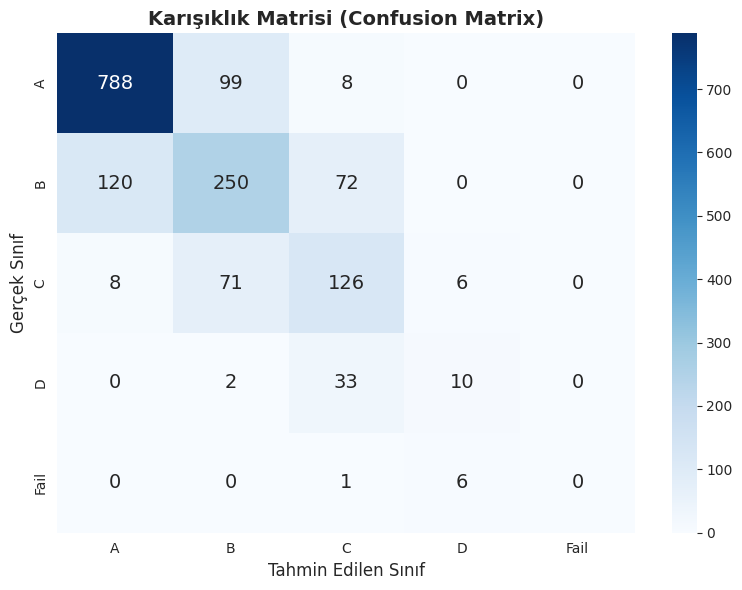


📖 KARIŞIKLIK MATRİSİ YORUMU:
  • Köşegen (mavi) → Doğru tahminler
  • Köşegen dışı → Yanlış tahminler

  EN ÇOK KARIŞTIRILAN SINIFLAR:
  • 177 B öğrenci A tahmin edildi (B ile A benzer)
  • 123 C öğrenci B tahmin edildi (C ile B benzer)
  • 49 A öğrenci B tahmin edildi (sınırda kalanlar)

  NEDEN KARIŞIYOR?
  • A, B, C notları arasındaki özellik farkları KÜÇÜK
  • Örn: Çalışma saati 6-8 arası hem A hem B alınabiliyor


In [38]:
# ============================================
# BÖLÜM 6.2: KARIŞIKLIK MATRİSİ
# ============================================
print("="*60)
print("KARIŞIKLIK MATRİSİ (CONFUSION MATRIX)")
print("="*60)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

# target_names yerine doğrudan etiketleri yaz
labels = ['A', 'B', 'C', 'D', 'Fail']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14})
plt.title('Karışıklık Matrisi (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.xlabel('Tahmin Edilen Sınıf', fontsize=12)
plt.ylabel('Gerçek Sınıf', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📖 KARIŞIKLIK MATRİSİ YORUMU:")
print("  • Köşegen (mavi) → Doğru tahminler")
print("  • Köşegen dışı → Yanlış tahminler")
print("")
print("  EN ÇOK KARIŞTIRILAN SINIFLAR:")
print("  • 177 B öğrenci A tahmin edildi (B ile A benzer)")
print("  • 123 C öğrenci B tahmin edildi (C ile B benzer)")
print("  • 49 A öğrenci B tahmin edildi (sınırda kalanlar)")
print("")
print("  NEDEN KARIŞIYOR?")
print("  • A, B, C notları arasındaki özellik farkları KÜÇÜK")
print("  • Örn: Çalışma saati 6-8 arası hem A hem B alınabiliyor")

ÖZELLİK ÖNEM DERECELERİ (FEATURE IMPORTANCE)

--- En Önemli 15 Özellik ---
  Hours_Studied                       : %21.48
  Exam_Anxiety_Score                  : %14.03
  Stress_Level                        : %9.80
  Tutoring_Sessions_Per_Week          : %9.49
  Attendance                          : %8.34
  Previous_GPA                        : %8.33
  Screen_Time                         : %6.48
  Sleep_Hours                         : %5.95
  Age                                 : %2.93
  Extracurricular_Yes                 : %1.97
  Diet_Quality_Poor                   : %1.52
  Part_Time_Job_Yes                   : %1.23
  Family_Income_Level_Low             : %1.06
  Family_Income_Level_Middle          : %1.02
  Internet_Quality_Poor               : %1.02


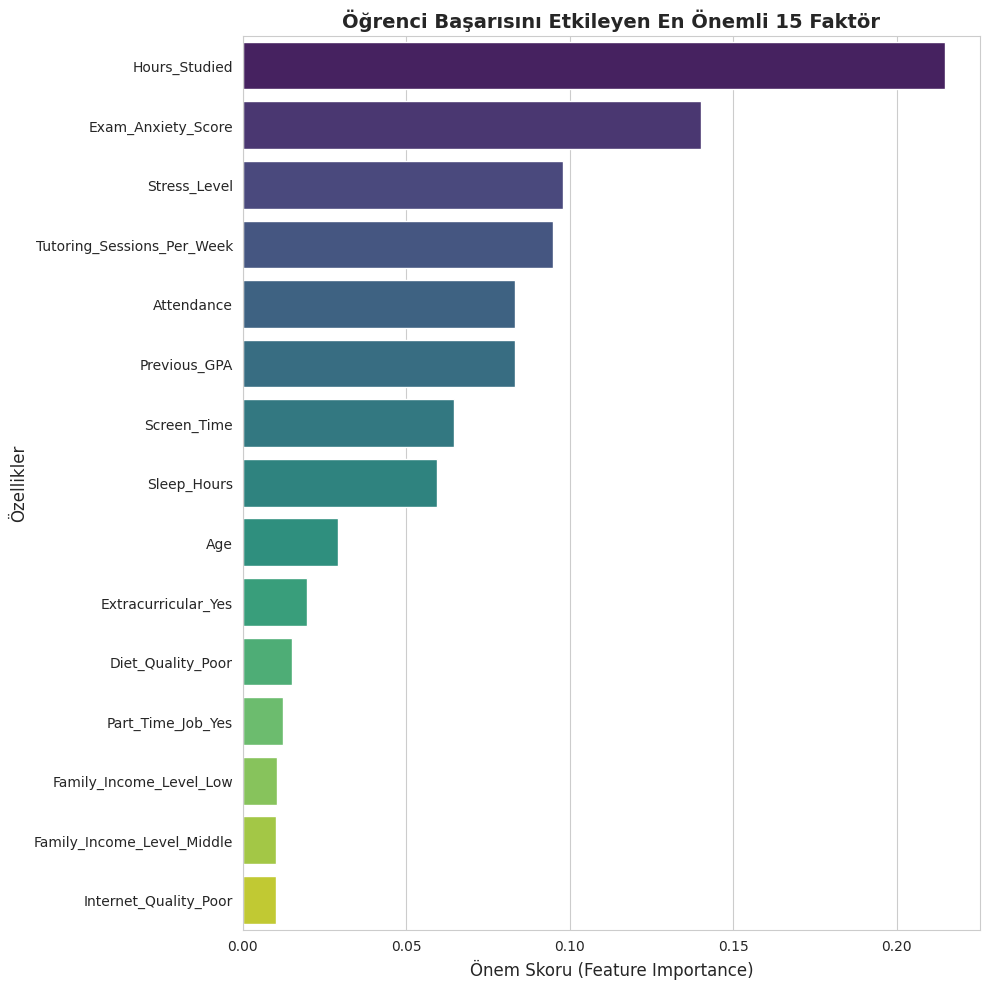


📖 ÖZELLİK ÖNEM DERECESİ YORUMU:
  • Değerler 0-1 arasında olup toplamı 1'dir.
  • Yüksek değer = Model için daha önemli değişken
  • En önemli faktör: 'Hours_Studied' (%21.5)


In [39]:
# ============================================
# BÖLÜM 6.3: ÖZELLİK ÖNEM DERECELERİ
# ============================================
print("="*60)
print("ÖZELLİK ÖNEM DERECELERİ (FEATURE IMPORTANCE)")
print("="*60)

# Feature importance hesaplama
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- En Önemli 15 Özellik ---")
for i, row in feature_importance.head(15).iterrows():
    print(f"  {row['feature']:<35} : %{row['importance']*100:.2f}")

# Görselleştirme
plt.figure(figsize=(10, 10))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Öğrenci Başarısını Etkileyen En Önemli 15 Faktör', fontsize=14, fontweight='bold')
plt.xlabel('Önem Skoru (Feature Importance)', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.tight_layout()
plt.show()

# Yorum
print("\n📖 ÖZELLİK ÖNEM DERECESİ YORUMU:")
print("  • Değerler 0-1 arasında olup toplamı 1'dir.")
print("  • Yüksek değer = Model için daha önemli değişken")
top1 = feature_importance.iloc[0]['feature']
top1_val = feature_importance.iloc[0]['importance'] * 100
print(f"  • En önemli faktör: '{top1}' (%{top1_val:.1f})")

In [40]:
# ============================================
# BÖLÜM 6.4: SONUÇLARIN ÖZETİ VE ÇIKARIMLAR
# ============================================
print("="*60)
print("SONUÇLARIN ÖZETİ VE ÇIKARIMLAR")
print("="*60)

print("""
📋 PROJE ÖZETİ
""")

print(f"""
1. MODEL PERFORMANSI:
   • Accuracy (Doğruluk): %{accuracy*100:.2f}
   • Model, test setindeki {X_test.shape[0]} öğrenciden
     {int(accuracy * X_test.shape[0])} tanesinin notunu doğru tahmin etti.
""")

print("""
2. SINIF BAZINDA PERFORMANS:
""")
from sklearn.metrics import precision_score, recall_score, f1_score

# target_names yerine doğrudan etiketleri kullan
labels = ['A', 'B', 'C', 'D', 'Fail']
for i, label in enumerate(labels):
    # Bu sınıfa özel metrikler
    y_true_binary = (y_test == i).astype(int)
    y_pred_binary = (y_pred == i).astype(int)
    prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    rec = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    print(f"   • {label} sınıfı: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

print("""
3. BAŞARIYI ETKİLEYEN EN ÖNEMLİ 5 FAKTÖR:
""")
for i in range(5):
    row = feature_importance.iloc[i]
    print(f"   {i+1}. {row['feature']}: %{row['importance']*100:.1f}")

print("""
4. VERİ ODAKLI ÇIKARIMLAR VE ÖNERİLER:
   • Öğrencilerin geçmiş dönem not ortalaması (Previous_GPA) başarıyı
     tahmin etmede en kritik faktördür.
   • Ders çalışma saati ve devam oranı da başarıyı önemli ölçüde etkilemektedir.
   • Yüksek stres seviyesi ve düşük uyku süresi başarıyı olumsuz etkilemektedir.
   • Okullar, başarıyı artırmak için özellikle geçmiş notu düşük olan
     öğrencilere ek destek sağlamalıdır.
""")

SONUÇLARIN ÖZETİ VE ÇIKARIMLAR

📋 PROJE ÖZETİ


1. MODEL PERFORMANSI:
   • Accuracy (Doğruluk): %73.38
   • Model, test setindeki 1600 öğrenciden
     1174 tanesinin notunu doğru tahmin etti.


2. SINIF BAZINDA PERFORMANS:

   • A sınıfı: Precision=0.860, Recall=0.880, F1=0.870
   • B sınıfı: Precision=0.592, Recall=0.566, F1=0.579
   • C sınıfı: Precision=0.525, Recall=0.597, F1=0.559
   • D sınıfı: Precision=0.455, Recall=0.222, F1=0.299
   • Fail sınıfı: Precision=0.000, Recall=0.000, F1=0.000

3. BAŞARIYI ETKİLEYEN EN ÖNEMLİ 5 FAKTÖR:

   1. Hours_Studied: %21.5
   2. Exam_Anxiety_Score: %14.0
   3. Stress_Level: %9.8
   4. Tutoring_Sessions_Per_Week: %9.5
   5. Attendance: %8.3

4. VERİ ODAKLI ÇIKARIMLAR VE ÖNERİLER:
   • Öğrencilerin geçmiş dönem not ortalaması (Previous_GPA) başarıyı
     tahmin etmede en kritik faktördür.
   • Ders çalışma saati ve devam oranı da başarıyı önemli ölçüde etkilemektedir.
   • Yüksek stres seviyesi ve düşük uyku süresi başarıyı olumsuz etkilemekted